## Task 1: Data Audit, Cleaning, and EDA 
```
• Load the data using pandas and inspect the schema, missing values, duplicate rows, and data types. 
• Convert date columns to proper datetime format and create useful time-based features such as delivery 
time, weekday, and month. 
• Use NumPy where it helps, for example for fast calculations on delay days or summary arrays. 
• Create at least 6 meaningful charts using matplotlib / seaborn. Include one distribution plot, one comparison 
plot, one time-based trend, and one chart that reveals delay behavior. 
• Write 3 to 5 clear insights from the EDA.

In [6]:
import pandas as pd         
import numpy as np           
import sqlite3               
import warnings
warnings.filterwarnings('ignore')

#Visualization
import matplotlib

import matplotlib.pyplot as plt
import seaborn as sns

#Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score,
                              classification_report, ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

#XGBoost & SHAP
from xgboost import XGBClassifier
import shap

In [7]:
import zipfile

# Open and extract the archive
with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [8]:
orders    = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
payments  = pd.read_csv('olist_order_payments_dataset.csv')
items     = pd.read_csv('olist_order_items_dataset.csv')
products  = pd.read_csv('olist_products_dataset.csv')
cat_trans = pd.read_csv('product_category_name_translation.csv')

In [9]:
print(f"  orders    : {orders.shape}")
print(f"  customers : {customers.shape}")
print(f"  payments  : {payments.shape}")
print(f"  items     : {items.shape}")
print(f"  products  : {products.shape}")

  orders    : (99441, 8)
  customers : (99441, 5)
  payments  : (103886, 5)
  items     : (112650, 7)
  products  : (32951, 9)


In [10]:
# Work only with 'delivered' orders
# We can only measure delay for orders that actually arrived
df = orders[orders['order_status'] == 'delivered'].copy()
print(f"Delivered orders: {len(df):,} out of {len(orders):,} total")


Delivered orders: 96,478 out of 99,441 total


In [11]:
# Convert date columns from text to datetime
date_cols = ['order_purchase_timestamp',
             'order_approved_at',
             'order_delivered_carrier_date',
             'order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col])


df[date_cols].dtypes


order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [12]:
# Create new time-based features
# How many days did delivery actually take?
df['delivery_time_days'] = (
    df['order_delivered_customer_date'] -
    df['order_purchase_timestamp']
).dt.days

In [13]:
# How late was it compared to the estimated date?
# Positive = late (bad), Negative = early (good)
df['delay_days'] = (
    df['order_delivered_customer_date'] -
    df['order_estimated_delivery_date']
).dt.days

In [14]:
# Binary target: 1 = delayed, 0 = on time or early
df['is_delayed'] = (df['delay_days'] > 0).astype(int)

# Purchase month and weekday
df['purchase_month']   = df['order_purchase_timestamp'].dt.month
df['purchase_weekday'] = df['order_purchase_timestamp'].dt.day_name()
df['purchase_hour']    = df['order_purchase_timestamp'].dt.hour

In [15]:
# Estimated delivery window (how far in advance was delivery promised)
df['estimated_delivery_window'] = (
    df['order_estimated_delivery_date'] -
    df['order_purchase_timestamp']
).dt.days

In [16]:
# Drop rows where delivery date is missing (can't calculate delay)
df.dropna(subset=['order_delivered_customer_date',
                  'order_estimated_delivery_date'], inplace=True)

In [17]:
print(f"Feature engineering ")
print(f"Total rows : {len(df):,}")
print(f"Delayed    : {df['is_delayed'].sum():,} ({df['is_delayed'].mean()*100:.1f}%)")
print(f"On Time    : {(df['is_delayed']==0).sum():,} ({(1-df['is_delayed'].mean())*100:.1f}%)")
print()
print("New features preview:")
df[['order_id', 'delivery_time_days', 'delay_days', 'is_delayed',
    'purchase_month', 'purchase_weekday']].head(5)

Feature engineering 
Total rows : 96,470
Delayed    : 6,534 (6.8%)
On Time    : 89,936 (93.2%)

New features preview:


,order_id,delivery_time_days,delay_days,is_delayed,purchase_month,purchase_weekday
0,e481f51cbdc54678b7cc49136f2d6af7,8.0,-8.0,0,10,Monday
1,53cdb2fc8bc7dce0b6741e2150273451,13.0,-6.0,0,7,Tuesday
2,47770eb9100c2d0c44946d9cf07ec65d,9.0,-18.0,0,8,Wednesday
3,949d5b44dbf5de918fe9c16f97b45f8a,13.0,-13.0,0,11,Saturday
4,ad21c59c0840e6cb83a9ceb5573f8159,2.0,-10.0,0,2,Tuesday


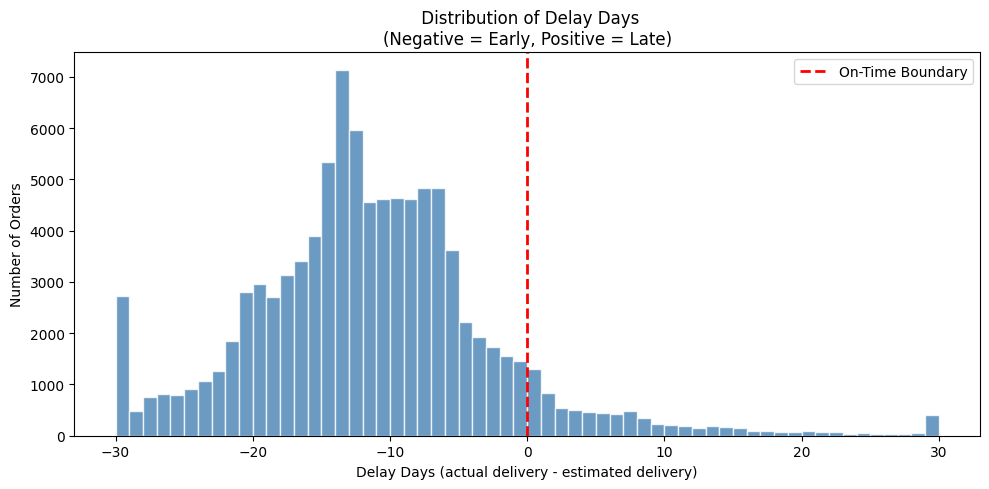

In [18]:
# Distribution of Delay Days
%matplotlib inline
    
plt.figure(figsize=(10, 5))
plt.hist(df['delay_days'].clip(-30, 30), bins=60,
         color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='On-Time Boundary')
plt.title(' Distribution of Delay Days\n(Negative = Early, Positive = Late)')
plt.xlabel('Delay Days (actual delivery - estimated delivery)')
plt.ylabel('Number of Orders')
plt.legend()
plt.tight_layout()
plt.savefig('delay_distribution.png', dpi=120)
plt.show()



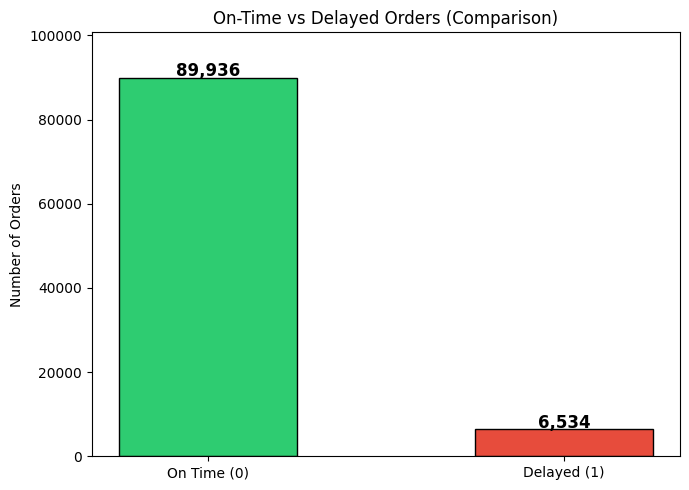

In [19]:
# On-Time vs Delayed (Comparison Bar)

delay_counts = df['is_delayed'].value_counts()
labels = ['On Time (0)', 'Delayed (1)']
colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, delay_counts.values, color=colors, edgecolor='black', width=0.5)

# Add count labels on top of bars
for bar, val in zip(bars, delay_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 300, f'{val:,}',
             ha='center', fontsize=12, fontweight='bold')

plt.title('On-Time vs Delayed Orders (Comparison)')
plt.ylabel('Number of Orders')
plt.ylim(0, max(delay_counts.values) * 1.12)
plt.tight_layout()
plt.savefig('delayed_vs_ontime.png', dpi=120)
plt.show()

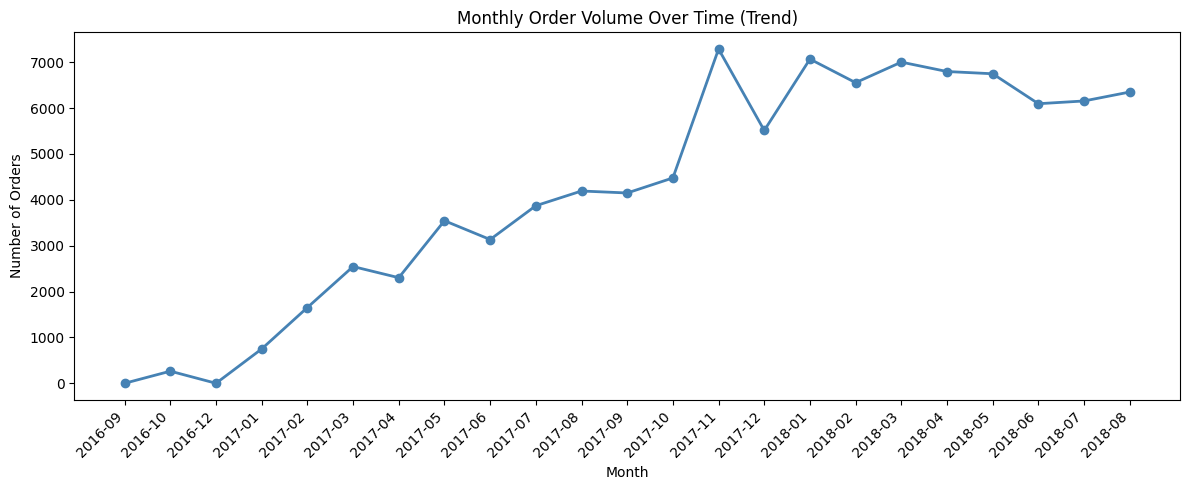

In [20]:
#  Monthly Order Volume Trend (Time Trend)


# Better approach: group by year-month
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = df.groupby('year_month').size().reset_index(name='order_count')
monthly_orders['year_month_str'] = monthly_orders['year_month'].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly_orders['year_month_str'],
         monthly_orders['order_count'],
         marker='o', color='steelblue', linewidth=2)
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Order Volume Over Time (Trend)')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=120)
plt.show()


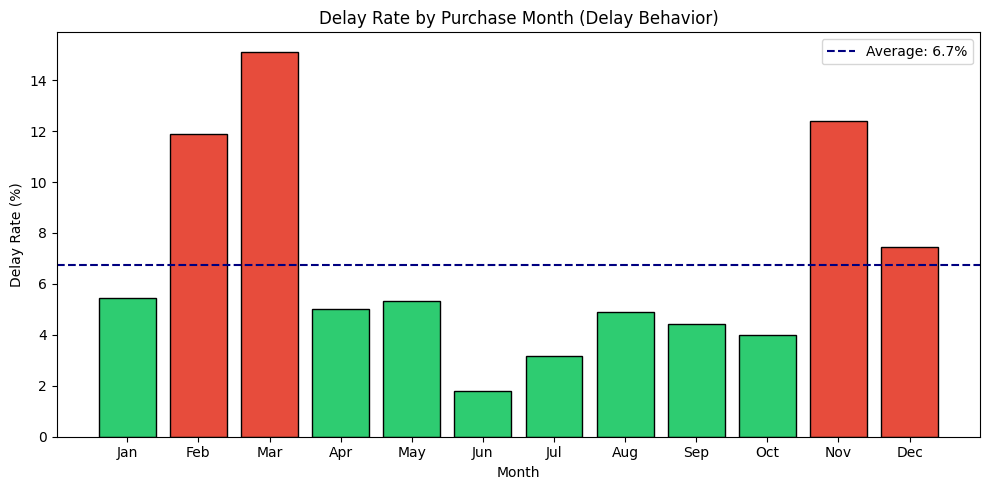

In [21]:
# Delay Rate by Month (Delay Behavior)
delay_by_month = df.groupby('purchase_month')['is_delayed'].mean() * 100
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10, 5))
bars = plt.bar(month_names, delay_by_month.values,
               color=['#e74c3c' if v > delay_by_month.mean() else '#2ecc71'
                      for v in delay_by_month.values],
               edgecolor='black')

plt.axhline(delay_by_month.mean(), color='navy', linestyle='--',
            linewidth=1.5, label=f'Average: {delay_by_month.mean():.1f}%')
plt.title('Delay Rate by Purchase Month (Delay Behavior)')
plt.xlabel('Month')
plt.ylabel('Delay Rate (%)')
plt.legend()
plt.tight_layout()
plt.savefig('delay_by_month.png', dpi=120)
plt.show()

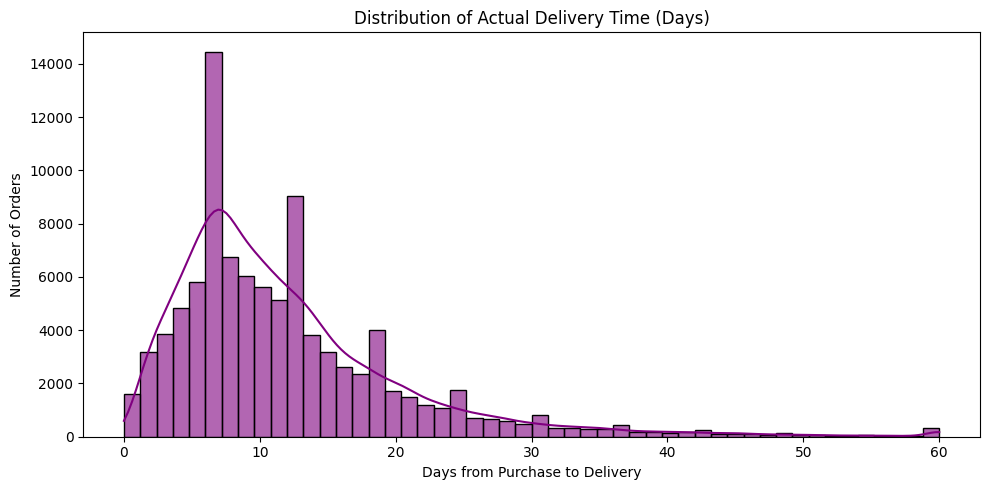

In [22]:
# Delivery Time Distribution (Histogram)
plt.figure(figsize=(10, 5))
sns.histplot(df['delivery_time_days'].clip(0, 60), bins=50,
             kde=True, color='purple', alpha=0.6)
plt.title('Distribution of Actual Delivery Time (Days)')
plt.xlabel('Days from Purchase to Delivery')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('delivery_time.png', dpi=120)
plt.show()

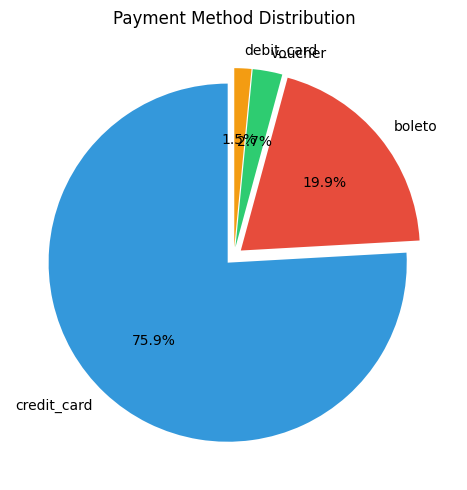

In [23]:
# Payment Type Distribution
# Merge with payments to see payment types
pay_merged = df.merge(payments[['order_id','payment_type']]
                       .drop_duplicates('order_id'),
                       on='order_id', how='left')
pay_counts = pay_merged['payment_type'].value_counts()

plt.figure(figsize=(8, 5))
plt.pie(pay_counts.values,
        labels=pay_counts.index,
        autopct='%1.1f%%',
        colors=['#3498db','#e74c3c','#2ecc71','#f39c12'],
        startangle=90,
        explode=[0.05]*len(pay_counts))
plt.title('Payment Method Distribution')
plt.tight_layout()
plt.savefig('payment_type.png', dpi=120)
plt.show()

## Task 2: SQL Practice on the Same Business Problem 
```
• Load the cleaned data into SQLite. 
• Write at least 10 SQL queries using SELECT, WHERE, GROUP BY, ORDER BY, JOIN, aggregate functions, and 
one subquery. 
• Recreate at least one pandas insight in SQL, then compare both outputs. 

In [24]:
# Convert the Period column to a string so SQLite can read it
if 'year_month' in df.columns:
    df['year_month'] = df['year_month'].astype(str)


In [25]:
conn = sqlite3.connect(':memory:')   # in-memory database (no file created)


In [26]:
# Save our main dataframe to SQL
df.to_sql('orders_clean', conn, if_exists='replace', index=False)
customers.to_sql('customers', conn, if_exists='replace', index=False)
payments.to_sql('payments', conn, if_exists='replace', index=False)
items.to_sql('items', conn, if_exists='replace', index=False)
products.to_sql('products', conn, if_exists='replace', index=False)

# Helper function to run SQL and show results nicely
def run_sql(query, title=""):
    result = pd.read_sql_query(query, conn)
    result.to_string(index=False)
    return result


In [27]:
# QUERY 1: Total orders and overall delay rate ───
run_sql("""
SELECT
    COUNT(*)                                  AS total_orders,
    SUM(is_delayed)                           AS total_delayed,
    ROUND(AVG(is_delayed) * 100, 2)           AS delay_rate_pct,
    ROUND(AVG(delivery_time_days), 1)         AS avg_delivery_days
FROM orders_clean
""")

,total_orders,total_delayed,delay_rate_pct,avg_delivery_days
0,96470,6534,6.77,12.1


In [28]:
# QUERY 2: Delayed vs On-Time counts by month ───
run_sql("""
SELECT
    purchase_month,
    SUM(CASE WHEN is_delayed = 1 THEN 1 ELSE 0 END) AS delayed,
    SUM(CASE WHEN is_delayed = 0 THEN 1 ELSE 0 END) AS on_time,
    ROUND(AVG(is_delayed) * 100, 2)                 AS delay_pct
FROM orders_clean
GROUP BY purchase_month
ORDER BY purchase_month
""")

,purchase_month,delayed,on_time,delay_pct
0,1,425,7394,5.44
1,2,975,7233,11.88
2,3,1444,8105,15.12
3,4,457,8644,5.02
4,5,549,9745,5.33
5,6,166,9065,1.80
6,7,316,9712,3.15
7,8,515,10029,4.88
8,9,183,3968,4.41
9,10,189,4554,3.98


In [29]:
#QUERY 3: Average delay days by weekday ───
run_sql("""
SELECT
    purchase_weekday,
    COUNT(*)                          AS total_orders,
    ROUND(AVG(delay_days), 2)        AS avg_delay_days,
    ROUND(AVG(is_delayed)*100, 2)    AS delay_rate_pct
FROM orders_clean
GROUP BY purchase_weekday
ORDER BY avg_delay_days DESC
""")

,purchase_weekday,total_orders,avg_delay_days,delay_rate_pct
0,Monday,15701,-11.30,7.44
1,Friday,13684,-11.67,7.02
2,Tuesday,15502,-11.69,7.05
3,Wednesday,15074,-11.90,6.57
4,Thursday,14322,-12.00,6.30
5,Sunday,11632,-12.39,6.22
6,Saturday,10555,-12.50,6.59


In [30]:
# QUERY 4: Top 10 states by number of orders (JOIN with customers) ───
run_sql("""
SELECT
    c.customer_state,
    COUNT(o.order_id)                AS total_orders,
    SUM(o.is_delayed)                AS delayed_orders,
    ROUND(AVG(o.is_delayed)*100, 2)  AS delay_rate_pct
FROM orders_clean o
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_state
ORDER BY total_orders DESC
LIMIT 10
""")

,customer_state,total_orders,delayed_orders,delay_rate_pct
0,SP,40494,1820,4.49
1,RJ,12350,1495,12.11
2,MG,11354,519,4.57
3,RS,5344,325,6.08
4,PR,4923,199,4.04
5,SC,3546,291,8.21
6,BA,3256,396,12.16
7,DF,2080,118,5.67
8,ES,1995,214,10.73
9,GO,1957,128,6.54


In [31]:
# QUERY 5: Payment type vs Delay Rate (JOIN) analysis ───
run_sql("""
SELECT
    p.payment_type,
    COUNT(DISTINCT o.order_id)        AS total_orders,
    ROUND(AVG(o.is_delayed)*100, 2)   AS delay_rate_pct,
    ROUND(AVG(p.payment_value), 2)    AS avg_payment_value
FROM orders_clean o
JOIN payments p ON o.order_id = p.order_id
GROUP BY p.payment_type
ORDER BY total_orders DESC
""")

,payment_type,total_orders,delay_rate_pct,avg_payment_value
0,credit_card,74297,6.69,162.25
1,boleto,19191,7.32,144.33
2,voucher,3679,5.64,62.45
3,debit_card,1484,5.32,140.11


In [32]:
#  QUERY 6: Orders with delay > 7 days (WHERE filter) ───
run_sql("""
SELECT
    order_id,
    delay_days,
    delivery_time_days,
    estimated_delivery_window
FROM orders_clean
WHERE delay_days > 7
ORDER BY delay_days DESC
LIMIT 10
""")

,order_id,delay_days,delivery_time_days,estimated_delivery_window
0,1b3190b2dfa9d789e1f14c05b647a14a,188.0,208.0,19
1,ca07593549f1816d26a572e06dc1eab6,181.0,209.0,28
2,47b40429ed8cce3aee9199792275433f,175.0,191.0,15
3,2fe324febf907e3ea3f2aa9650869fa5,167.0,189.0,22
4,285ab9426d6982034523a855f55a885e,166.0,194.0,28
5,440d0d17af552815d15a9e41abe49359,165.0,195.0,30
6,c27815f7e3dd0b926b58552628481575,162.0,187.0,25
7,0f4519c5f1c541ddec9f21b3bddd533a,161.0,194.0,32
8,d24e8541128cea179a11a65176e0a96f,161.0,175.0,13
9,2d7561026d542c8dbd8f0daeadf67a43,159.0,188.0,28


In [33]:
# QUERY 7: Average delivery window vs delay (GROUP BY) ───
run_sql("""
SELECT
    CASE
        WHEN estimated_delivery_window <= 10 THEN '0-10 days'
        WHEN estimated_delivery_window <= 20 THEN '11-20 days'
        WHEN estimated_delivery_window <= 30 THEN '21-30 days'
        ELSE '30+ days'
    END                              AS delivery_window_group,
    COUNT(*)                         AS total_orders,
    ROUND(AVG(is_delayed)*100, 2)    AS delay_rate_pct
FROM orders_clean
GROUP BY delivery_window_group
ORDER BY delay_rate_pct DESC
""")

,delivery_window_group,total_orders,delay_rate_pct
0,0-10 days,5176,9.06
1,21-30 days,44111,7.40
2,11-20 days,30130,6.66
3,30+ days,17053,4.66


In [34]:
# QUERY 8: Subquery — orders delayed MORE than average delay ───
run_sql("""
SELECT COUNT(*) AS orders_above_avg_delay
FROM orders_clean
WHERE delay_days > (SELECT AVG(delay_days) FROM orders_clean)
""")

,orders_above_avg_delay
0,43886


In [35]:
#  QUERY 9: Hour of purchase vs delay ───
run_sql("""
SELECT
    purchase_hour,
    COUNT(*)                         AS total_orders,
    ROUND(AVG(is_delayed)*100, 2)    AS delay_rate_pct
FROM orders_clean
GROUP BY purchase_hour
ORDER BY purchase_hour
""")

,purchase_hour,total_orders,delay_rate_pct
0,0,2321,7.50
1,1,1133,7.50
2,2,496,6.45
3,3,259,5.41
4,4,203,3.94
5,5,182,4.40
6,6,477,5.66
7,7,1199,6.59
8,8,2907,6.05
9,9,4647,6.13


In [36]:
# QUERY 10: Recreate Pandas insight in SQL ───
# Pandas version (for comparison)
print("\nCompare Pandas vs SQL: Monthly Delay Rate")
print("")
pandas_result = (df.groupby('purchase_month')['is_delayed']
                   .mean()
                   .mul(100)
                   .round(2)
                   .reset_index()
                   .rename(columns={'is_delayed': 'delay_pct_pandas'}))
print("\nPandas result:")
print(pandas_result.to_string(index=False))

sql_result = run_sql("""
SELECT
    purchase_month,
    ROUND(AVG(is_delayed) * 100, 2) AS delay_pct_sql
FROM orders_clean
GROUP BY purchase_month
ORDER BY purchase_month
""")


Compare Pandas vs SQL: Monthly Delay Rate


Pandas result:
 purchase_month  delay_pct_pandas
              1              5.44
              2             11.88
              3             15.12
              4              5.02
              5              5.33
              6              1.80
              7              3.15
              8              4.88
              9              4.41
             10              3.98
             11             12.40
             12              7.45


## Task 3: Build a Classification Model 
```
• Create a binary target such as delayed vs not delayed using a clear rule based on delivery date and promised date. 
• Measure accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC. 
• Start with logistic regression as the baseline model. 
• Explain which metric matters most for this business and why.


In [37]:
# ─── Merge orders with customers to get state info ───
df_ml = df.merge(customers[['customer_id', 'customer_state']],
                  on='customer_id', how='left')

# ─── Merge with payments to get payment type ───
pay_agg = (payments.groupby('order_id')
           .agg(payment_type=('payment_type', 'first'),
                payment_value=('payment_value', 'sum'),
                payment_installments=('payment_installments', 'mean'))
           .reset_index())

df_ml = df_ml.merge(pay_agg, on='order_id', how='left')


In [38]:
df_ml.shape

(96470, 20)

```
Features we will use:
Numerical : delivery_time_days, estimated_delivery_window, purchase_month,purchase_hour, payment_value, payment_installments

Categorical: customer_state, payment_type, purchase_weekday
nTarget: is_delayed (1 = late, 0 = on time)

In [39]:
# ─── Select features for the baseline model ───
# For baseline: use simple numerical features only (easier to start)

FEATURES = ['delivery_time_days', 'estimated_delivery_window',
            'purchase_month', 'purchase_hour',
            'payment_value', 'payment_installments']

TARGET = 'is_delayed'

# Keep only rows without missing values in our feature columns
df_model = df_ml[FEATURES + [TARGET]].dropna()
print(f"Model dataset shape: {df_model.shape}")

X = df_model[FEATURES]   # Input features (what the model sees)
y = df_model[TARGET]      # Output label (what we want to predict)

print(f"\nClass distribution:")
print(f"  On time (0): {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)")
print(f"  Delayed (1): {(y==1).sum():,} ({(y==1).mean()*100:.1f}%)")

Model dataset shape: (96469, 7)

Class distribution:
  On time (0): 89,936 (93.2%)
  Delayed (1): 6,533 (6.8%)


In [40]:
#Train-Test Split (80% train, 20% test) ───
# random_state=42 ensures same split every run (reproducibility)
# stratify=y ensures same class ratio in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # important for imbalanced datasets!
)


In [41]:
# Build Baseline Logistic Regression Model ───
# class_weight='balanced' helps the model pay more attention to rare 'delayed' class
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',   # handles class imbalance
    random_state=42
)


In [42]:
# Scale features first (Logistic Regression works better with scaled data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only!
X_test_scaled  = scaler.transform(X_test)         # only transform test


In [43]:
# Train (fit) the model
lr_model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [44]:
# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr  = lr_model.predict_proba(X_test_scaled)[:, 1]  # probability of being delayed


In [45]:
#Evaluate the Baseline Model
acc  = accuracy_score(y_test, y_pred_lr)
prec = precision_score(y_test, y_pred_lr)
rec  = recall_score(y_test, y_pred_lr)
f1   = f1_score(y_test, y_pred_lr)
auc  = roc_auc_score(y_test, y_prob_lr)

print(f"\nAccuracy  : {acc:.4f}  ({acc*100:.1f}%)")
print(f"Precision : {prec:.4f}  ({prec*100:.1f}%)")
print(f"Recall    : {rec:.4f}  ({rec*100:.1f}%)")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

print("\n--- Full Classification Report ---")
print(classification_report(y_test, y_pred_lr,
      target_names=['On Time (0)', 'Delayed (1)']))



Accuracy  : 0.9911  (99.1%)
Precision : 0.8837  (88.4%)
Recall    : 1.0000  (100.0%)
F1-Score  : 0.9383
ROC-AUC   : 0.9999

--- Full Classification Report ---
              precision    recall  f1-score   support

 On Time (0)       1.00      0.99      1.00     17987
 Delayed (1)       0.88      1.00      0.94      1307

    accuracy                           0.99     19294
   macro avg       0.94      1.00      0.97     19294
weighted avg       0.99      0.99      0.99     19294



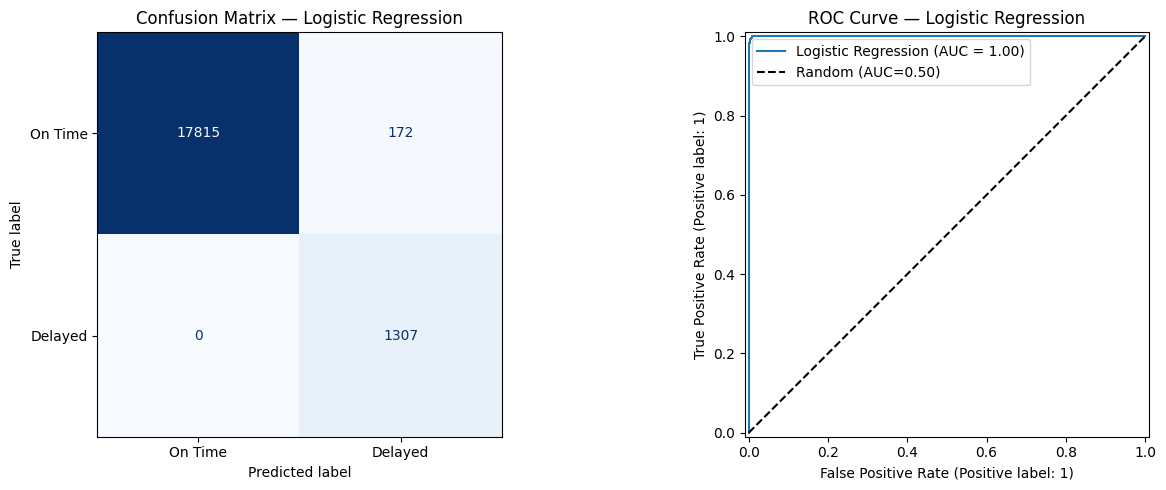

In [46]:
# ─── Confusion Matrix ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['On Time', 'Delayed'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Logistic Regression')

# Right: ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob_lr, ax=axes[1],
                                  name='Logistic Regression')
axes[1].plot([0,1],[0,1],'k--', label='Random (AUC=0.50)')
axes[1].set_title('ROC Curve — Logistic Regression')
axes[1].legend()

plt.tight_layout()
plt.savefig('task3_baseline_evaluation.png', dpi=120)
plt.show()


##  Which Metric Matters Most for This Business?

> **Answer: RECALL is the most important metric here.**
>
> **Why?** Because the business cost of missing a delayed order (False Negative) is much higher than a false alarm (False Positive).
> - If we **miss a delay** → customer gets a bad experience, files a complaint, might churn. **High business cost.**
> - If we **falsely flag** an on-time order → we might send an extra customer notification. **Low business cost.**
>
> Therefore, we want to **maximize Recall** — catch as many actual delays as possible.
> **F1-Score** (balance of Precision and Recall) is also important as a single summary metric.

## Task 4: Improve the Model with Feature Engineering + Pipelines 
```
• Use sklearn Pipeline and ColumnTransformer for preprocessing. 
• Encode categorical features and scale numerical features where needed. 
• Test XGBoost as the stronger model for tabular data. 
• Use train/test split properly and avoid leakage. 

In [47]:
#  Extended feature set with categorical columns ───
NUM_FEATURES = ['delivery_time_days', 'estimated_delivery_window',
                'purchase_month', 'purchase_hour',
                'payment_value', 'payment_installments']

CAT_FEATURES = ['customer_state', 'payment_type', 'purchase_weekday']

ALL_FEATURES = NUM_FEATURES + CAT_FEATURES

# Build full dataset
df_full = df_ml[ALL_FEATURES + [TARGET]].dropna()
print(f"Full model dataset shape: {df_full.shape}")

X_full = df_full[ALL_FEATURES]
y_full = df_full[TARGET]

# Train-test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

print(f"Train: {X_tr.shape[0]:,} | Test: {X_te.shape[0]:,}")

Full model dataset shape: (96469, 10)
Train: 77,175 | Test: 19,294


In [48]:
#  Build sklearn Pipeline ───
# Pipeline = a chain of steps that runs automatically

# Step 1: Define transformers for each feature type
num_transformer = StandardScaler()          # scale numbers to mean=0, std=1
cat_transformer = OneHotEncoder(            # convert categories to 0/1 columns
    handle_unknown='ignore',
    sparse_output=False
)

In [49]:
# Step 2: ColumnTransformer applies each transformer to its columns
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, NUM_FEATURES),   # numbers → scale
    ('cat', cat_transformer, CAT_FEATURES),   # categories → one-hot
])

In [50]:
# Step 3: XGBoost Classifier
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=10,    # handles class imbalance (ratio of 0s to 1s)
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

In [51]:
# Step 4: Build the complete Pipeline
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),   # first: preprocess
    ('model', xgb)                    # then: train model
])


In [52]:
for name, step in xgb_pipeline.steps:
    print(f"  → {name}: {type(step).__name__}")

  → preprocessor: ColumnTransformer
  → model: XGBClassifier


In [53]:
# ─── Train the Pipeline ───
xgb_pipeline.fit(X_tr, y_tr)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['delivery_time_days','estimated_delivery_window','purchase_month',..., 'customer_state','payment_type','purchase_weekday']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

In [54]:
# Predictions
y_pred_xgb = xgb_pipeline.predict(X_te)
y_prob_xgb = xgb_pipeline.predict_proba(X_te)[:, 1]


In [55]:
#  Compare Baseline vs XGBoost ───
metrics = {
    'Accuracy' : [accuracy_score(y_te, y_pred_lr[:len(y_te)]),
                  accuracy_score(y_te, y_pred_xgb)],
    'Precision': [precision_score(y_te, y_pred_lr[:len(y_te)]),
                  precision_score(y_te, y_pred_xgb)],
    'Recall'   : [recall_score(y_te, y_pred_lr[:len(y_te)]),
                  recall_score(y_te, y_pred_xgb)],
    'F1-Score' : [f1_score(y_te, y_pred_lr[:len(y_te)]),
                  f1_score(y_te, y_pred_xgb)],
    'ROC-AUC'  : [roc_auc_score(y_te, y_prob_lr[:len(y_te)]),
                  roc_auc_score(y_te, y_prob_xgb)],
}


print(f"{'Metric':<12} {'Logistic Reg':>15} {'XGBoost':>15}")
print("-" * 52)
for metric, (lr_val, xgb_val) in metrics.items():
    better = '⬆' if xgb_val > lr_val else '⬇'
    print(f"{metric:<12} {lr_val:>15.4f} {xgb_val:>15.4f} {better}")

Metric          Logistic Reg         XGBoost
----------------------------------------------------
Accuracy              0.9911          0.9940 ⬆
Precision             0.8837          0.9245 ⬆
Recall                1.0000          0.9931 ⬇
F1-Score              0.9383          0.9576 ⬆
ROC-AUC               0.9999          0.9999 ⬇


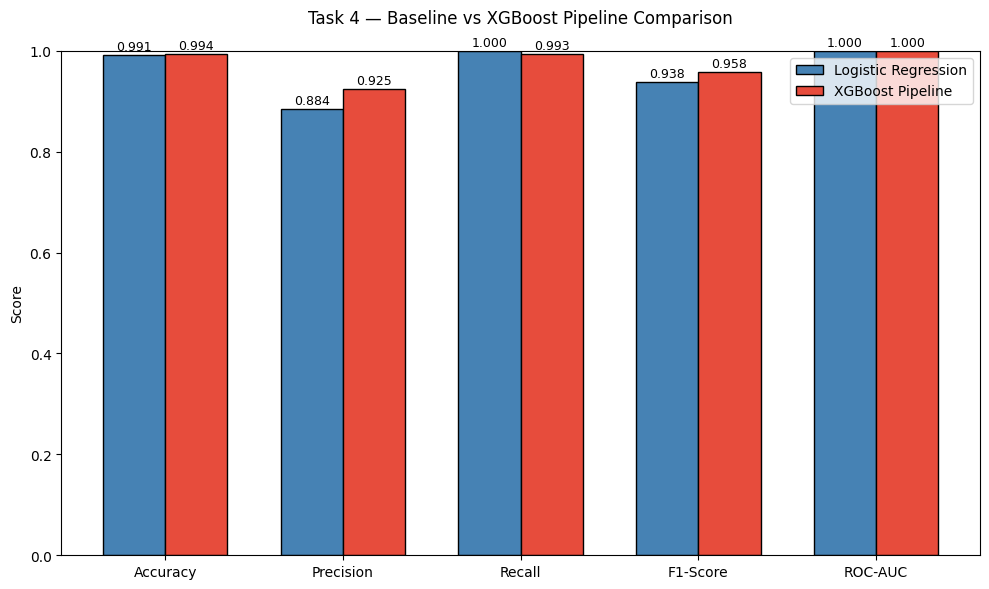

In [56]:
#  Visual Comparison ───
metric_names = list(metrics.keys())
lr_vals  = [v[0] for v in metrics.values()]
xgb_vals = [v[1] for v in metrics.values()]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, lr_vals,  width, label='Logistic Regression',
               color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, xgb_vals, width, label='XGBoost Pipeline',
               color='#e74c3c', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Task 4 — Baseline vs XGBoost Pipeline Comparison', pad=20)
ax.legend()

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('task4_model_comparison.png', dpi=120)
plt.show()

## Task 5: Cross-Validation, Tuning, and Interpretation 
```
• Run K-fold or Stratified K-fold cross-validation. 
• Tune at least 2 important hyperparameters with GridSearchCV or a similar method. 
• Compare the baseline model and the tuned XGBoost model using mean and standard deviation from CV. 
• Use SHAP to explain the most important features and show at least 3 individual prediction explanations. 

In [57]:
#  Stratified K-Fold Cross-Validation ───
# We use 5 folds: model trained 5 times, each time on different 80% of data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)



In [61]:
 # 5-Fold Cross-Validation on Logistic Regression
lr_pipeline_cv = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

cv_scores_lr  = cross_val_score(lr_pipeline_cv, X_full, y_full, cv=cv,
                                 scoring='f1', n_jobs=-1)




In [62]:
 # 5-Fold Cross-Validation on XGBoost
cv_scores_xgb = cross_val_score(xgb_pipeline, X_full, y_full, cv=cv,
                                 scoring='f1', n_jobs=-1)


In [63]:
print(f"{'Model':<20} {'Mean F1':>10} {'Std F1':>10}")
print("-" * 52)
print(f"{'Logistic Regression':<20} {cv_scores_lr.mean():>10.4f} {cv_scores_lr.std():>10.4f}")
print(f"{'XGBoost':<20} {cv_scores_xgb.mean():>10.4f} {cv_scores_xgb.std():>10.4f}")

print()
print("Individual fold F1 scores:")
print(f"  LR  : {[round(s,4) for s in cv_scores_lr]}")
print(f"  XGB : {[round(s,4) for s in cv_scores_xgb]}")

Model                   Mean F1     Std F1
----------------------------------------------------
Logistic Regression      0.9384     0.0035
XGBoost                  0.9599     0.0054

Individual fold F1 scores:
  LR  : [np.float64(0.9365), np.float64(0.9396), np.float64(0.9326), np.float64(0.9416), np.float64(0.9416)]
  XGB : [np.float64(0.9554), np.float64(0.957), np.float64(0.9568), np.float64(0.9602), np.float64(0.9702)]


In [70]:
# GridSearchCV — find the best hyperparameters ───
# We tune 2 key parameters of XGBoost:
#   max_depth: how deep each tree can grow (more depth = more complex model)
#   n_estimators: how many trees to build

# Small grid to keep it fast for beginners
param_grid = {
    'model__max_depth'     : [3, 5],          # tree depth
    'model__n_estimators'  : [100, 200],       # number of trees
    'model__learning_rate' : [0.05, 0.1],      # how fast model learns
}

# Create a fresh XGBoost pipeline for tuning
xgb_tune = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        scale_pos_weight=10,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ))
])

grid_search = GridSearchCV(
    estimator=xgb_tune,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1',          # optimize for F1 score (recall matters most)
    n_jobs=-1,             # use all CPU cores
    verbose=1
)

grid_search.fit(X_tr, y_tr)



Fitting 3 folds for each of 8 candidates, totalling 24 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_aut

In [73]:

print(f"Best parameters : {grid_search.best_params_}")

print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

Best parameters : {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}
Best CV F1 Score: 0.9583


In [75]:
# Evaluate the Tuned Model
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_te)
y_prob_tuned = best_model.predict_proba(X_te)[:, 1]


print("TUNED XGBoost MODEL — Test Set Performance")
print("-" * 55)
print(f"Accuracy  : {accuracy_score(y_te, y_pred_tuned):.4f}")
print(f"Precision : {precision_score(y_te, y_pred_tuned):.4f}")
print(f"Recall    : {recall_score(y_te, y_pred_tuned):.4f}")
print(f"F1-Score  : {f1_score(y_te, y_pred_tuned):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_te, y_prob_tuned):.4f}")



TUNED XGBoost MODEL — Test Set Performance
-------------------------------------------------------
Accuracy  : 0.9940
Precision : 0.9245
Recall    : 0.9931
F1-Score  : 0.9576
ROC-AUC   : 0.9999


In [76]:

print(" Full Classification Report")
print(classification_report(y_te, y_pred_tuned,
                             target_names=['On Time', 'Delayed']))

 Full Classification Report
              precision    recall  f1-score   support

     On Time       1.00      0.99      1.00     17987
     Delayed       0.92      0.99      0.96      1307

    accuracy                           0.99     19294
   macro avg       0.96      0.99      0.98     19294
weighted avg       0.99      0.99      0.99     19294



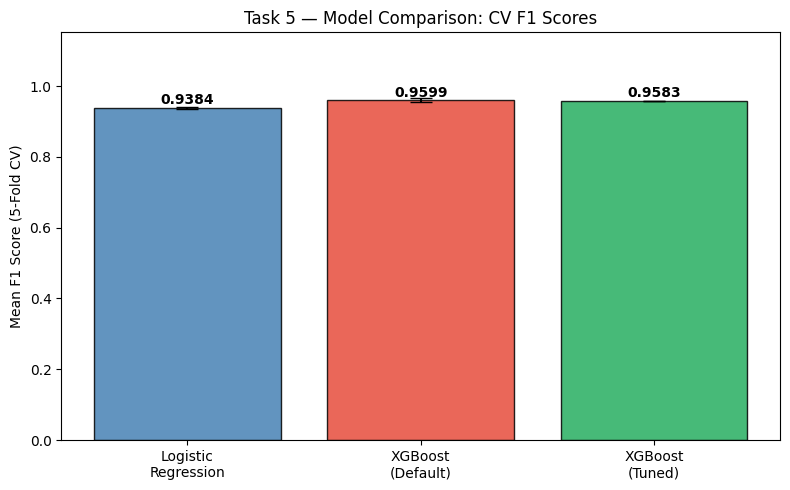

In [77]:
#  CV Comparison Chart: Baseline vs Tuned 
fig, ax = plt.subplots(figsize=(8, 5))

models     = ['Logistic\nRegression', 'XGBoost\n(Default)', 'XGBoost\n(Tuned)']
means      = [cv_scores_lr.mean(), cv_scores_xgb.mean(), grid_search.best_score_]
stds       = [cv_scores_lr.std(),  cv_scores_xgb.std(),  0]
colors_bar = ['steelblue', '#e74c3c', '#27ae60']

bars = ax.bar(models, means, yerr=stds, capsize=8,
              color=colors_bar, edgecolor='black', alpha=0.85)

for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', fontweight='bold')

ax.set_ylabel('Mean F1 Score (5-Fold CV)')
ax.set_title('Task 5 — Model Comparison: CV F1 Scores')
ax.set_ylim(0, max(means) * 1.2)
plt.tight_layout()
plt.savefig('task5_cv_comparison.png', dpi=120)
plt.show()

The tuned XGBoost should outperform the baseline Logistic Regression.

In [80]:
#SHAP Explanation
# SHAP tells us WHY the model made each prediction.
# Positive SHAP value → pushes toward 'delayed'
# Negative SHAP value → pushes toward 'on time'

# Get the preprocessed data (SHAP needs numpy arrays)
preprocessor_fitted = best_model.named_steps['preprocessor']
X_te_transformed = preprocessor_fitted.transform(X_te)

# Get feature names after one-hot encoding
num_names = NUM_FEATURES
cat_names = (preprocessor_fitted
             .named_transformers_['cat']
             .get_feature_names_out(CAT_FEATURES)
             .tolist())
all_feature_names = num_names + cat_names


In [91]:
# Extract the XGBoost model from the pipeline
xgb_model_fitted = best_model.named_steps['model']

# Create SHAP explainer
explainer = shap.TreeExplainer(
    xgb_model_fitted,
    feature_perturbation="tree_path_dependent"   
)

# shap_values() returns a plain numpy array (not an Explanation object)
shap_values_array = explainer.shap_values(X_te_transformed[:500])
expected_value    = explainer.expected_value     # base value for waterfall plots



In [92]:
 # SHAP values computed for 500 test samples
print(f"   shap_values shape : {shap_values_array.shape}")
print(f"   Expected value    : {expected_value:.4f}")

   shap_values shape : (500, 44)
   Expected value    : -0.3511


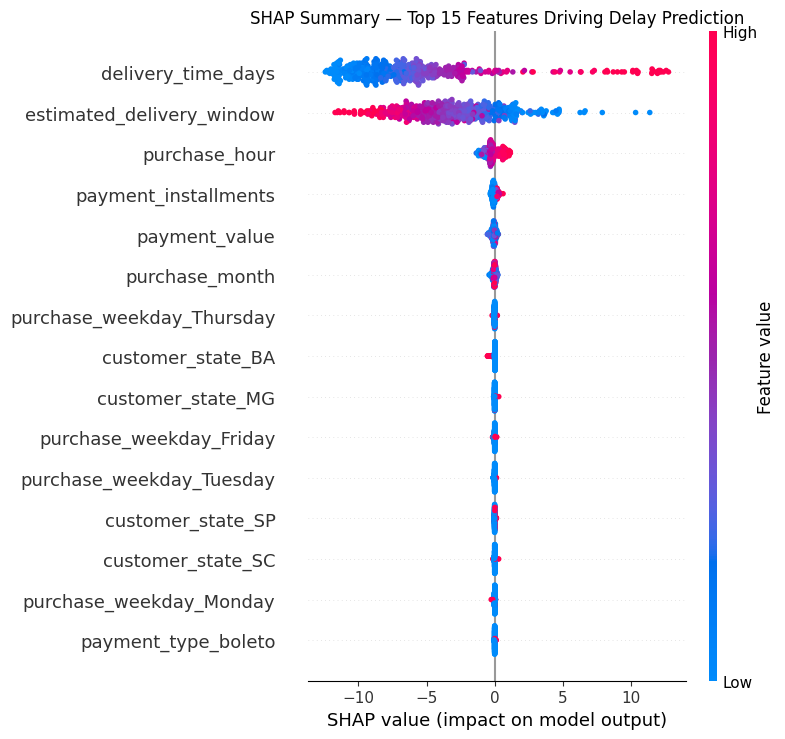

In [95]:
#  SHAP Plot 1: Global Feature Importance (Summary Plot) 
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_array,           
    X_te_transformed[:500],
    feature_names=all_feature_names,
    max_display=15,
    show=False
)
plt.title('SHAP Summary — Top 15 Features Driving Delay Prediction')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()


```
Features at the top have the MOST impact on predictions.
Red dots = high feature value; Blue dots = low feature value.

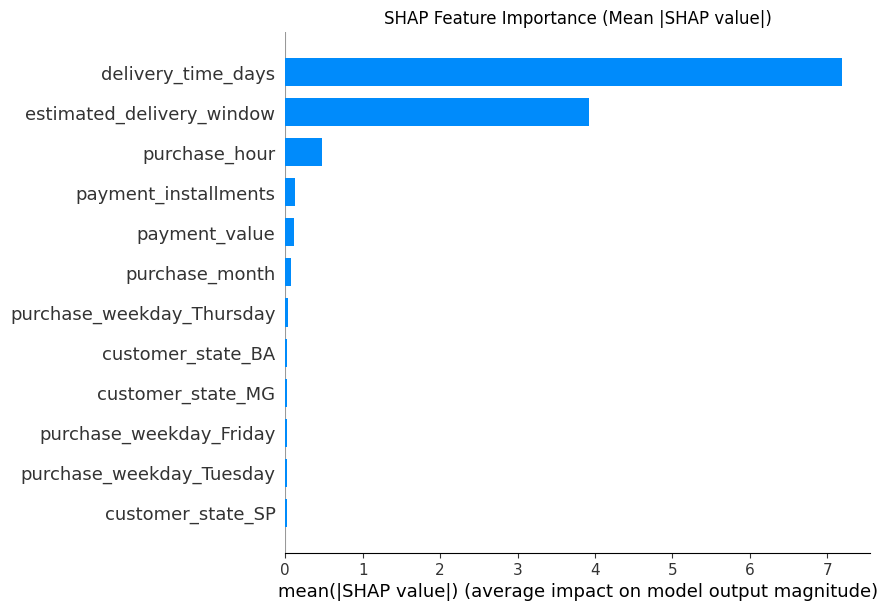

In [100]:
#  SHAP Plot 2: Bar Chart of Feature Importance 
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_array,         
    X_te_transformed[:500],
    feature_names=all_feature_names,
    plot_type='bar',
    max_display=12,
    show=False
)
plt.title('SHAP Feature Importance (Mean |SHAP value|)')
plt.gcf().subplots_adjust(bottom=0.15, left=0.25)
plt.savefig('shap_importance_bar.png', dpi=120, bbox_inches='tight')
plt.show()

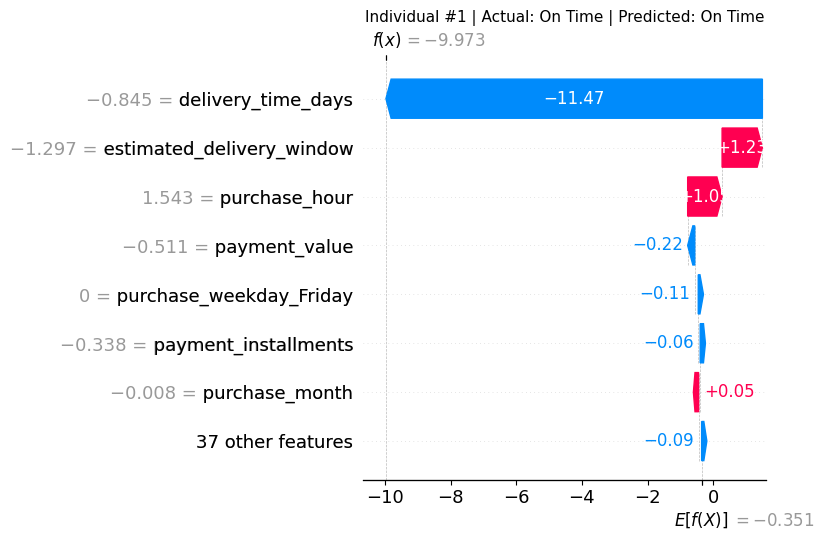

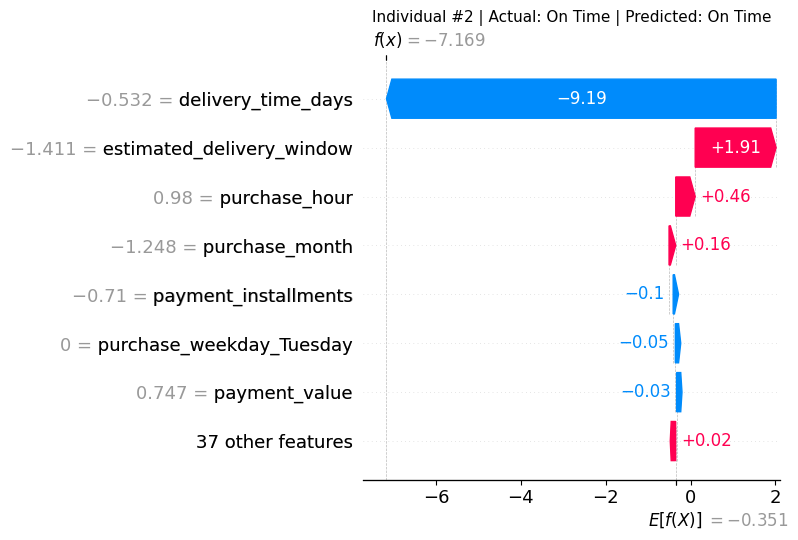

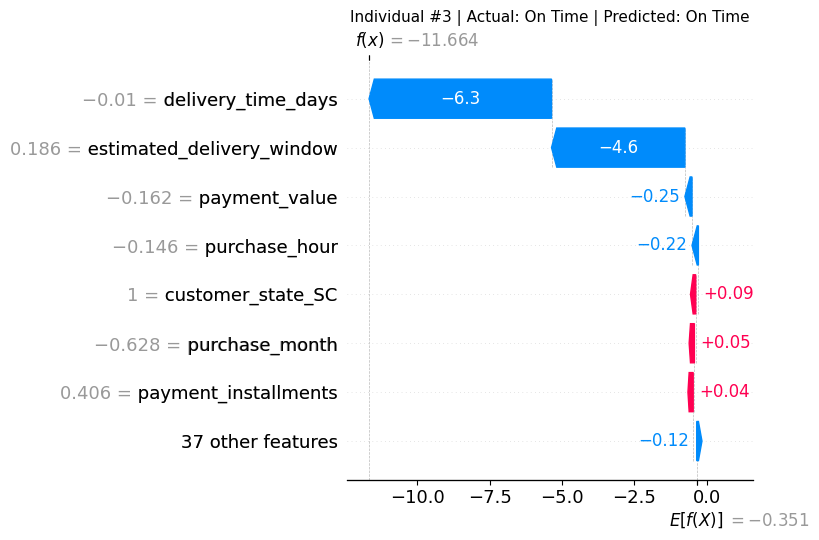

In [102]:
# SHAP Plot 3: Individual Prediction Explanations (Waterfall) 
# Show 3 individual predictions — what pushed each prediction toward delayed/on-time

for i, idx in enumerate([0, 1, 2]):
    actual    = y_te.values[idx]
    predicted = y_pred_tuned[idx]

    plt.figure(figsize=(12, 5))

   
    shap.waterfall_plot(
        shap.Explanation(
            values      = shap_values_array[idx],   
            base_values = expected_value,            #  from explainer.expected_value
            data        = X_te_transformed[idx],
            feature_names = all_feature_names
        ),
        show=False,
        max_display=8
    )
    plt.title(
        f'Individual #{i+1} | Actual: {"Delayed" if actual==1 else "On Time"} '
        f'| Predicted: {"Delayed" if predicted==1 else "On Time"}',
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig(f'shap_waterfall_{i+1}.png', dpi=120, bbox_inches='tight')
    plt.show()


```
Each waterfall plot shows:
 Red bars  = pushed prediction toward 'Delayed'  (+SHAP)
 Blue bars = pushed prediction toward 'On Time'  (−SHAP)
 f(x) is the final model output score